In [1]:
# %matplotlib widget
import sys
sys.path.append('..')

import os
import sys
import numpy as np
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits import mplot3d
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
import math
from IPython.display import HTML
from tqdm import tqdm
import random
from numpy.lib import recfunctions as rfn
import multiprocessing

from sklearn.cluster import DBSCAN
from scipy.interpolate import interp1d
from scipy.spatial import KDTree
from scipy.interpolate import interpn
# import cupy as cp
import time
import numba as nb

# 画图部分
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

# ROC曲线部分
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

# 插值
import torch
import torch.cuda as cuda
from scipy.interpolate import griddata

# 系数拟合部分
from scipy.optimize import curve_fit
from sklearn import svm


# 概率比较部分
from scipy.special import gammaln
import torch.distributions as dist

# 位置重建函数
import position_rec as pos

import DE
from DE import DESimulation
import importlib

# from thundersvm import SVC

Trans into torch tensor input


In [2]:
importlib.reload(DE)
importlib.reload(mpl)
from DE import DESimulation

In [3]:
file_load_once = 10
param = 0

test_DE_sim = DESimulation('DE_param_30_test.yaml')

# test_cevns_sim.pe_gain_std = 2.4e6

muon_file_list = []
for i in range(file_load_once):
    # print(i)
    file_index = param * file_load_once + i
    filename = test_DE_sim.load_folder_path + \
        "muon_track/muon_track." + str(file_index) + ('.npy')
    # print(filename)
    muon_file_list.append(filename)

generate_muon_points
====

In [4]:
test_DE_sim.generate_muon_points(muon_file_list)
print(test_DE_sim.time_range/3600)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 184.25it/s]


/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.0.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.1.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.2.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.3.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.4.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.5.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.6.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.7.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.8.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.9.npy
Number of muon events: 31255
merged_muon_array data type: [('eventId', '<i4'), ('type', 'i1'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('td', '<f8')]
dense_muon_points data type:  [('eventId', '<i4'), ('energy', '<f8'), ('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8'), ('muon_time', '<f8'), ('num_e',

In [5]:
# 获取默认的颜色循环
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# 打印默认的颜色循环
color_list = []
for i, color in enumerate(default_colors, start=1):
    print(f'默认颜色{i}: {color}')
    color_list.append(color)

默认颜色1: #1f77b4
默认颜色2: #ff7f0e
默认颜色3: #2ca02c
默认颜色4: #d62728
默认颜色5: #9467bd
默认颜色6: #8c564b
默认颜色7: #e377c2
默认颜色8: #7f7f7f
默认颜色9: #bcbd22
默认颜色10: #17becf


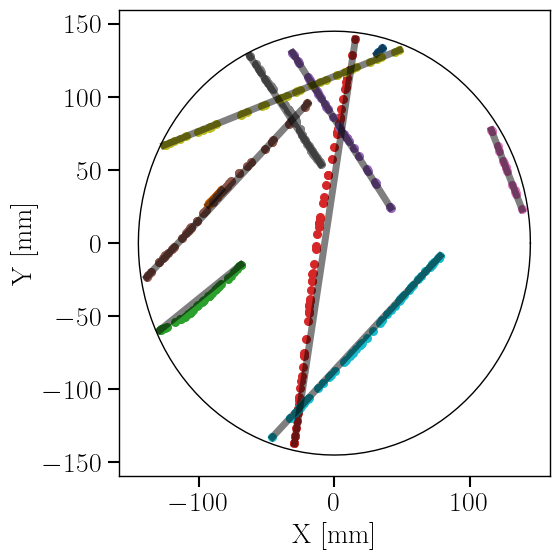

In [6]:
merged_muon_array = test_DE_sim.merged_muon_array
dense_muon_array = test_DE_sim.dense_muon_points

fig = plt.figure(figsize=(6,6))
plt.style.use('../relics.mplstyle')

angle = np.arange(121)*np.pi/60
outer_r = 14/np.cos(np.pi/12) * 10
plt.plot(outer_r*np.cos(angle), outer_r*np.sin(angle), c='k', lw=1)

for i in range(10):
    points = merged_muon_array[merged_muon_array['eventId'] == i]
    plt.scatter(points['xd'],points['yd'], marker = 'o', s=30 ,c = color_list[i])
    points_inter = dense_muon_array[dense_muon_array['eventId'] == i]
    plt.plot(points_inter['xd'],points_inter['yd'],color = 'black',alpha = 0.5,linewidth = 5)
    
plt.ylabel(r'$\mathrm{Y\ [mm]}$')
plt.xlabel(r'$\mathrm{X\ [mm]}$')
plt.tight_layout()
plt.savefig("Muon_Track.png")
plt.show()

In [7]:
dense_muon_array = test_DE_sim.dense_muon_points

angle = np.arange(121)*np.pi/60
outer_r = 14/np.cos(np.pi/12) * 10
dis_var_array = []
# plt.plot(outer_r*np.cos(angle), outer_r*np.sin(angle), c='k', lw=1)

for i in tqdm(range(100)):
    points = merged_muon_array[merged_muon_array['eventId'] == i]
    edges_start,edges_end = dense_muon_array[dense_muon_array['eventId'] == i][0],dense_muon_array[dense_muon_array['eventId'] == i][-1]
    dis_start_x = points['xd'] - edges_start['xd']
    dis_start_y = points['yd'] - edges_start['yd']
    
    dis_end_x = points['xd'] - edges_end['xd']
    dis_end_y = points['yd'] - edges_end['yd']
    
    l = np.sqrt((edges_start['xd'] - edges_end['xd'])**2 + (edges_start['yd'] - edges_end['yd'])**2)
    die_i = np.abs((dis_start_x * dis_end_y - dis_start_y * dis_end_x) / l)
    dis = np.max(die_i)
    dis_var_array.append(dis)
    
dis_var_array = np.array(dis_var_array)  


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 24.68it/s]


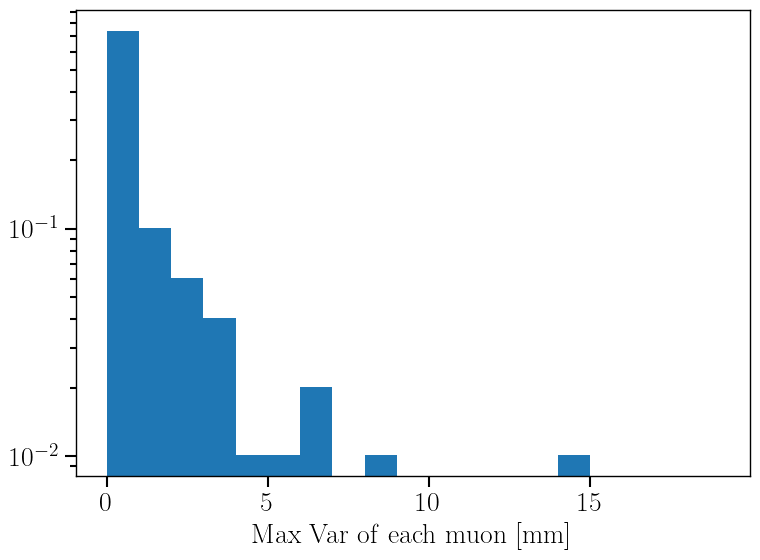

In [8]:
fig = plt.figure(figsize=(8,6))
plt.style.use('../relics.mplstyle')  
plt.hist(dis_var_array,bins = np.arange(0,20,1),density = True,log=True)
plt.yscale('log')
plt.xlabel(r'$\mathrm{Max\ Var\ of\ each\ muon\ [mm]}$')
plt.tight_layout()
# plt.savefig("Muon_var.png")
plt.show()

In [9]:
energy_array = []
width_array = []
# plt.plot(outer_r*np.cos(angle), outer_r*np.sin(angle), c='k', lw=1)

for i in tqdm(range(1000)):
    points = merged_muon_array[merged_muon_array['eventId'] == i]
    energy = np.sum(points['energy'])
    time = (points[0]['zd'] - points[-1]['zd']) / 1.7
    energy_array.append(energy)
    width_array.append(time)
    
energy_array = np.array(energy_array)  
width_array = np.array(width_array)  


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:03<00:00, 275.85it/s]


/tmp/ipykernel_230240/3323159848.py:3: RuntimeWarning: divide by zero encountered in divide
  plt.hist((energy_array / width_array)[width_array > 0]/1e3,bins = np.linspace(0,10,100),density = True,log=True)


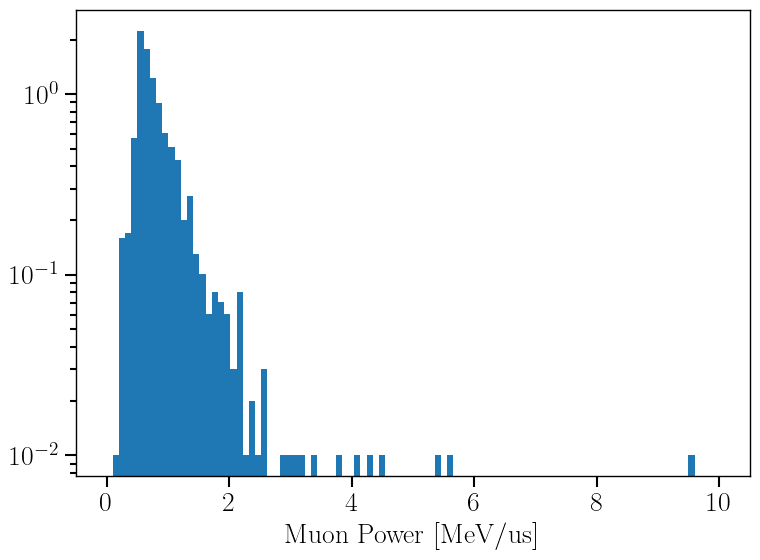

In [10]:
fig = plt.figure(figsize=(8,6))
plt.style.use('../relics.mplstyle')  
plt.hist((energy_array / width_array)[width_array > 0]/1e3,bins = np.linspace(0,10,100),density = True,log=True)
plt.yscale('log')
plt.xlabel(r'$\mathrm{Muon\ Power\ [MeV/ us]}$')
plt.tight_layout()
# plt.savefig("Muon_power.png")
plt.show()

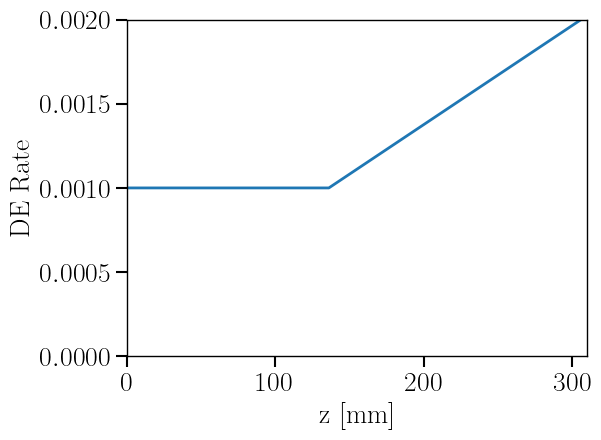

In [11]:
z_array = np.arange(-210,100,1)
delay_ratio = ((z_array-100) / (-1.7) / 1000 + 0.02) / 100
delay_ratio[delay_ratio < 0.001] = 0.001
fig = plt.figure()
plt.style.use('../relics.mplstyle')
plt.plot(-(z_array - 100),delay_ratio)
plt.ylim(0,0.002)
plt.xlim(0,310)
plt.ylabel(r'$\mathrm{DE\ Rate}$')
plt.xlabel(r'$\mathrm{z\ [mm]}$')
plt.tight_layout()
plt.savefig("DE_rate.png")
plt.show()

generate_DE_points
===

In [12]:
test_DE_sim.generate_DE_points()

Start sorting DE's time
Finish sorting DE's time


generate_Pile_UP_3e
=====

In [13]:
test_DE_sim.clean_pile_up()
test_DE_sim.generate_Pile_UP_2e()
test_DE_sim.generate_Pile_UP_3e()
test_DE_sim.generate_Pile_UP_multi_e()

In [14]:
event_rate = np.array([len(i) for i in test_DE_sim.pile_up_result]) / test_DE_sim.time_range

test_DE_sim.pile_up_e_num,test_DE_sim.pile_up_result[0].shape,event_rate,test_DE_sim.time_range

([2, 3, 4, 5, 6],
 (2171467, 2),
 array([7.12150021e+02, 3.76708981e+01, 2.42459365e+00, 2.02350099e-01,
        1.93495233e-02]),
 3049.170731707317)

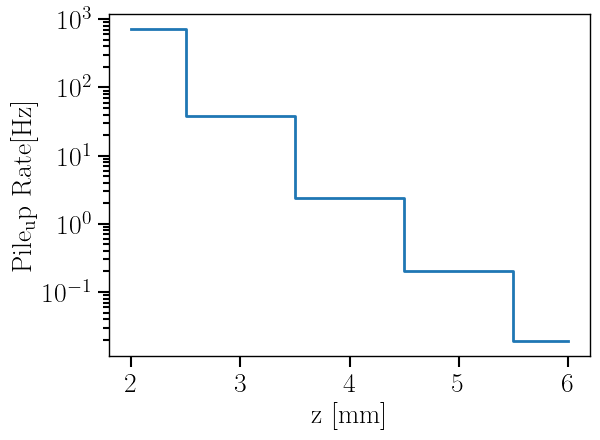

In [15]:
fig = plt.figure()
plt.style.use('../relics.mplstyle')
plt.yscale('log')
plt.plot(test_DE_sim.pile_up_e_num,event_rate,drawstyle='steps-mid')
# plt.ylim(0,800)
# plt.xlim(1,6)
plt.ylabel(r'$\mathrm{Pile_up\ Rate [Hz]}$')
plt.xlabel(r'$\mathrm{z\ [mm]}$')
plt.tight_layout()
# plt.savefig("Pile_up_Rate.png")
plt.show()

generate_DE_pattern
=====

In [16]:
test_DE_sim.generate_DE_pattern_linear()

Interpn for channel:  0
Interpn for channel:  1
Interpn for channel:  2
Interpn for channel:  3
Interpn for channel:  4
Interpn for channel:  5
Interpn for channel:  6
Interpn for channel:  7
Interpn for channel:  8
Interpn for channel:  9
Interpn for channel:  10
Interpn for channel:  11
Interpn for channel:  12
Interpn for channel:  13
Interpn for channel:  14
Interpn for channel:  15
Interpn for channel:  16
Interpn for channel:  17
Interpn for channel:  18
Interpn for channel:  19
Interpn for channel:  20
Interpn for channel:  21
Interpn for channel:  22
Interpn for channel:  23
Interpn for channel:  24
Interpn for channel:  25
Interpn for channel:  26
Interpn for channel:  27
Interpn for channel:  28
Interpn for channel:  29
Interpn for channel:  30
Interpn for channel:  31
Interpn for channel:  32
Interpn for channel:  33
Interpn for channel:  34
Interpn for channel:  35
Interpn for channel:  36
Interpn for channel:  37
Interpn for channel:  38
Interpn for channel:  39
Interpn fo

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 59/59 [00:00<00:00, 24518.37it/s]


In [17]:
def pattern_plot(phe_pmt, electron = [] , pos_recons = [], pmt_info = test_DE_sim.pmt_info,title = "",savefig = False):
    artists = list()
    # cmap = mpl.cm.viridis
    # 定义灰度色图
    cmap = cm.get_cmap("viridis")
    norm = mpl.colors.LogNorm(vmin=1, vmax=phe_pmt.max(), clip=True)
    colors = ['blue', 'green', 'yellow','red']  # 自定义颜色列表
    #norm = mpl.colors.LogNorm(vmin=1, vmax=1000, clip=True)
    fig = plt.figure(figsize=(7, 6))

    # grid = ImageGrid(fig, 111, (1,1), cbar_mode='single', axes_pad=0.1, cbar_pad=0.2)
    grid = ImageGrid(fig, 111, (1,1))

    # PMT plot
    # for pmt_id in range(64):
    #     pmt = pmt_info[pmt_id]
    #     pe_value = phe_pmt[pmt_id]
    #     # print(str(round(pe_value,2)))
    #     # grid[0].text(pmt['x'], pmt['y'], str(pmt['ChannelID']), ha='center', va='center')
    #     grid[0].text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
    #     # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc=cmap(norm(phe_pmt[pmt_id])),alpha = 0.86))
    #     # grid[0].add_patch(artists[pmt['ChannelID']])
    for pmt_id in range(64):
        pmt = pmt_info[pmt_id]
        pe_value = phe_pmt[pmt_id]
        # 检查 PMT 值并设定颜色
        if phe_pmt[pmt_id] < 0.5:
            pmt_color = 'white'  # 小于0.1的通道颜色为白色
        else:
            pmt_color = cmap(norm(phe_pmt[pmt_id]))
            # 绘制alpha为1的白色边框
        grid[0].text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
        border = Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc='none', ec='black', lw=1, alpha=1)    
        grid[0].add_patch(border)

        # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
        #                angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
        #                alpha=(phe_pmt[i][pmt_id] / vmax)**0))

        artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
                       angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
                       alpha=1))
        grid[0].add_patch(artists[pmt['ChannelID']])
    # event plot
    if len(electron)>0:
        grid[0].plot(electron['xd']/10, electron['yd']/10, 'ro', markersize=12 ,label = 'DE Position')
  
    # recon_pos plot
    if len(pos_recons)>0:
        grid[0].plot(pos_recons['xd']/10, pos_recons['yd']/10, 'b*', markersize=12, label = 'Recon Position')
        
    # muon_point_plot
    # if muon_id_list is not None:
        # for i, muon_id in enumerate(muon_id_list):
            # color = colors[i % len(colors)]  # 从颜色列表中选择颜色
            # grid[0].plot(dense_muon_points[dense_muon_points['eventId'] == muon_id]['xd']/10, dense_muon_points[dense_muon_points['eventId'] == muon_id]['yd']/10, 'o', label="muon id: {}".format(muon_id), markersize=2, alpha=0.5, color=color)
            
    # TPC outline
    angle = np.arange(13)*np.pi/6
    outer_r = 14/np.cos(np.pi/12)
    grid[0].plot(outer_r*np.cos(angle), outer_r*np.sin(angle), c='k', lw=3)

    # Colorbar
    # grid.cbar_axes[0].colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm))

    # Other settings
    grid[0].axis('equal')
    grid[0].set_xlabel('x/cm')
    grid[0].set_ylabel('y/cm')
    # grid[0].legend(bbox_to_anchor=(1.2, 0), loc=3, borderaxespad=0, prop={'size': 7})
    grid[0].set_title(title)
    if savefig == True: 
        plt.savefig(title+".png")
    plt.show()
    return 0

In [18]:
test_DE_sim.area_select_mask[0]

array([False, False, False, ..., False, False, False])

/tmp/ipykernel_230240/1059758695.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("viridis")


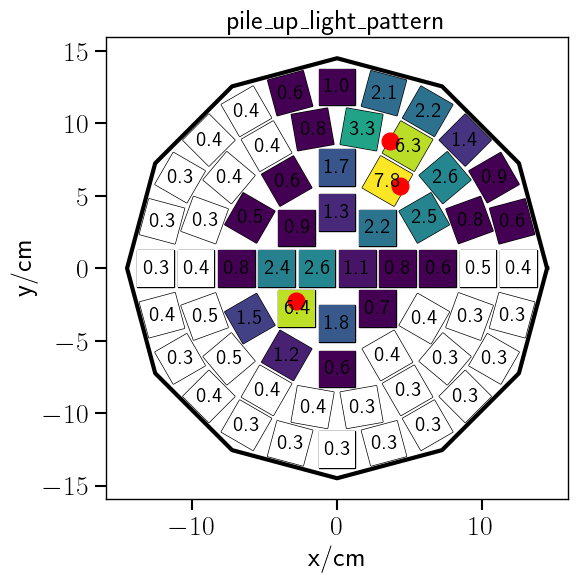

0

In [19]:
i = 101
pattern_plot(test_DE_sim.pile_up_light_pattern[1][i],test_DE_sim.pile_up_result[1][i],pos_recons = [], pmt_info = test_DE_sim.pmt_info,title = "pile_up_light_pattern")

/tmp/ipykernel_230240/1059758695.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("viridis")


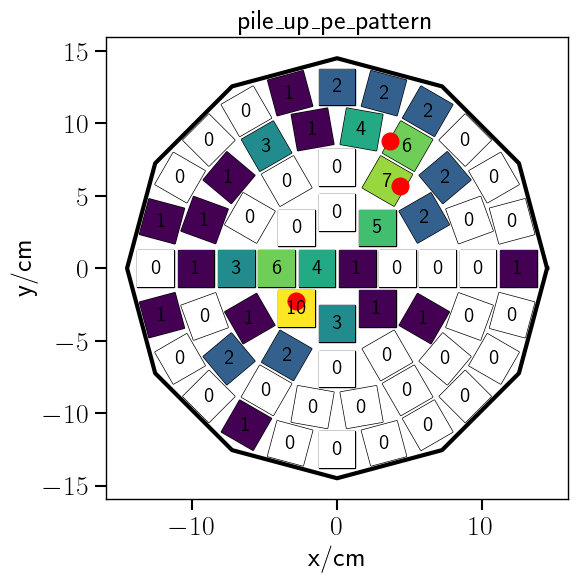

0

In [20]:
pattern_plot(test_DE_sim.pile_up_pe_pattern[1][i],test_DE_sim.pile_up_result[1][i],pos_recons = [], pmt_info = test_DE_sim.pmt_info,title = "pile_up_pe_pattern")

/tmp/ipykernel_230240/1059758695.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("viridis")


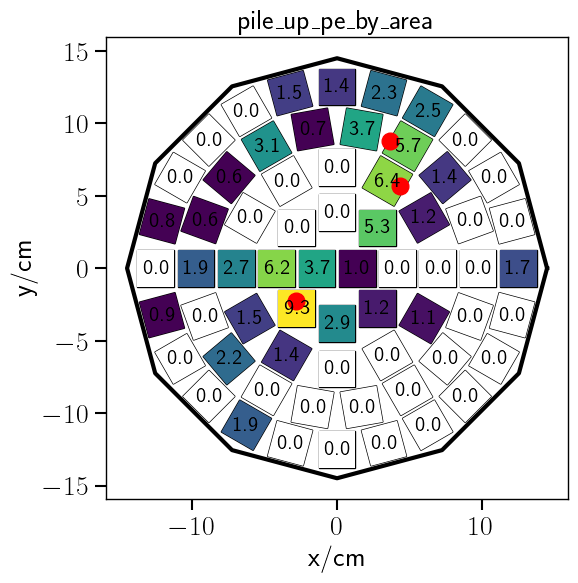

0

In [21]:
pattern_plot(test_DE_sim.pile_up_pe_by_area[1][i],test_DE_sim.pile_up_result[1][i],pos_recons = [], pmt_info = test_DE_sim.pmt_info,title = "pile_up_pe_by_area")

DE_position_recon, generate_DE_recon_pattern
====== 

In [22]:
test_DE_sim.DE_position_recon()
test_DE_sim.generate_DE_recon_pattern()

Start pos recon for event size:  2
(54134, 64)
54134
10000 / 54134 ,time: 0.07522726058959961
20000 / 54134 ,time: 0.07497358322143555
30000 / 54134 ,time: 0.07644009590148926
40000 / 54134 ,time: 0.07603883743286133
50000 / 54134 ,time: 0.07605528831481934
done of generating test files
Start pos recon for event size:  3
(58463, 64)
58463
10000 / 58463 ,time: 0.07613205909729004
20000 / 58463 ,time: 0.07615256309509277
30000 / 58463 ,time: 0.07732200622558594
40000 / 58463 ,time: 0.07577347755432129
50000 / 58463 ,time: 0.07594895362854004
done of generating test files
Start pos recon for event size:  4
(6991, 64)
6991
done of generating test files
Start pos recon for event size:  5
(616, 64)
616
done of generating test files
Start pos recon for event size:  6
(57, 64)
57
done of generating test files
Interpn for channel:  0
Interpn for channel:  1
Interpn for channel:  2
Interpn for channel:  3
Interpn for channel:  4
Interpn for channel:  5
Interpn for channel:  6
Interpn for channel

In [23]:
test_DE_sim.pile_up_pe_by_area[0].shape,test_DE_sim.pile_up_recons_pattern[0].shape

((54134, 128), (54134, 128))

In [24]:
test_DE_sim.pile_up_result[1][i]

array([(58, -27.99648812, -22.38402104, 5.85666955, 5.88548633),
       (58,  43.72652985,  56.4336358 , 5.85666955, 5.8854872 ),
       (43,  36.25140272,  88.03285435, 4.69730614, 5.88548786)],
      dtype=[('eventId', '<i4'), ('xd', '<f8'), ('yd', '<f8'), ('muon_time', '<f8'), ('e_time', '<f8')])

In [25]:
test_DE_sim.pile_up_pos_recon[1][i]

(0.83983219, 15.60782337)

/tmp/ipykernel_230240/1059758695.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("viridis")


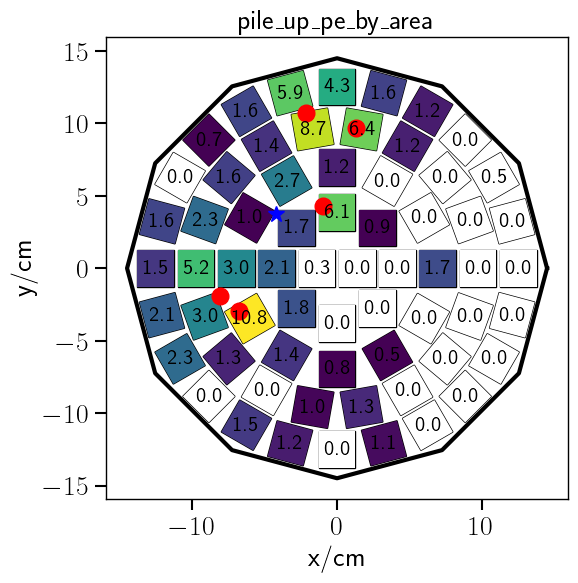

0

In [40]:
i = 50
pattern_plot(test_DE_sim.pile_up_pe_by_area[3][i],
             test_DE_sim.pile_up_result[3][i],
             pos_recons = test_DE_sim.pile_up_pos_recon[3][i], 
             pmt_info = test_DE_sim.pmt_info,
             title = "pile_up_pe_by_area")

/tmp/ipykernel_230240/1059758695.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("viridis")


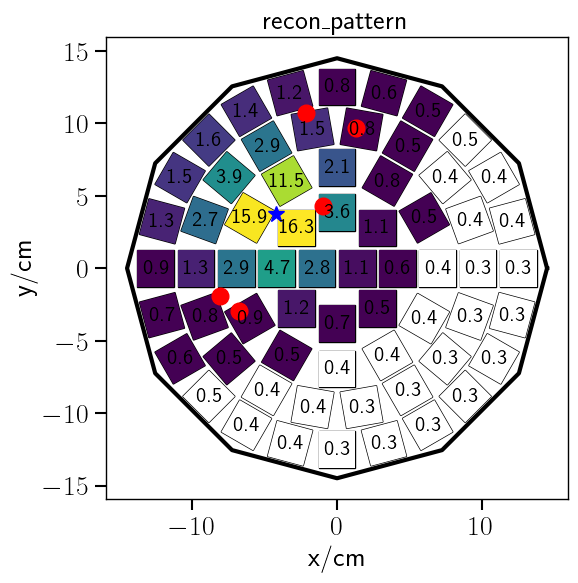

0

In [41]:
pattern_plot(test_DE_sim.pile_up_recons_light_pattern[3][i],
            test_DE_sim.pile_up_result[3][i],
            pos_recons = test_DE_sim.pile_up_pos_recon[3][i], 
            pmt_info = test_DE_sim.pmt_info,
            title = "recon_pattern")

In [166]:
def pattern_plot_duo(phe_pmt_0,phe_pmt_1, electron = [] , pos_recons = [], pmt_info = test_DE_sim.pmt_info,title = "",savefig = False):
    artists = list()
    # cmap = mpl.cm.viridis
    # 定义灰度色图
    cmap = cm.get_cmap("summer")
    vmax = np.max([phe_pmt_0,phe_pmt_1])
    norm = mpl.colors.LogNorm(vmin=1, vmax=vmax, clip=True)
    colors = ['blue', 'green', 'yellow','red']  # 自定义颜色列表
    #norm = mpl.colors.LogNorm(vmin=1, vmax=1000, clip=True)
    fig = plt.figure(figsize=(5.5,10))
    plt.style.use('../relics.mplstyle') 
    gs = matplotlib.gridspec.GridSpec(2,2, height_ratios=[0.45,0.45], width_ratios=[0,0.9])
    gs.update(left=0.16, right=0.9, bottom=0.08, top=0.9, wspace=0, hspace=0)

    # PMT plot
    # for pmt_id in range(64):
    #     pmt = pmt_info[pmt_id]
    #     pe_value = phe_pmt[pmt_id]
    #     # print(str(round(pe_value,2)))
    #     # grid[0].text(pmt['x'], pmt['y'], str(pmt['ChannelID']), ha='center', va='center')
    #     grid[0].text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
    #     # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc=cmap(norm(phe_pmt[pmt_id])),alpha = 0.86))
    #     # grid[0].add_patch(artists[pmt['ChannelID']])
    ax_label = plt.subplot(gs[:2,0])
    ax_label.set_ylabel(r'$\mathrm{y\ [cm]}$', labelpad=40)
    ax_label.set_yticks([])
    ax_label.set_yticklabels([])
    ax_label.set_xticks([])
    ax_label.set_xticklabels([])
    
    
    ax1 = plt.subplot(gs[0,1])
    for pmt_id in range(64):
        pmt = pmt_info[pmt_id]
        pe_value = phe_pmt_0[pmt_id]
        # 检查 PMT 值并设定颜色
        if pe_value < 0.5:
            pmt_color = 'white'  # 小于0.1的通道颜色为白色
        else:
            pmt_color = cmap(norm(pe_value))
            # 绘制alpha为1的白色边框
        ax1.text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
        border = Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc='none', ec='black', lw=1, alpha=1)    
        ax1.add_patch(border)

        # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
        #                angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
        #                alpha=(phe_pmt[i][pmt_id] / vmax)**0))

        artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
                       angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
                       alpha=1))
        ax1.add_patch(artists[pmt['ChannelID']])
    # event plot
    if len(electron)>0:
        ax1.scatter(electron['xd']/10, electron['yd']/10, c ='b', marker='.', s=160  ,label =r'$\mathrm{Pile\text{-}up\ DE}$')

    # recon_pos plot
    if len(pos_recons)>0:
        ax1.scatter(pos_recons['xd']/10, pos_recons['yd']/10, c = 'r', marker='*', s=180, label = r'$\mathrm{Reconstructed\ Position}$')
        
    # TPC outline
    angle = np.arange(13)*np.pi/6
    outer_r = 14/np.cos(np.pi/12)
    ax1.plot(outer_r*np.cos(angle), outer_r*np.sin(angle), c='k', lw=3)

    # Other settings
    ax1.axis('equal')
    ax1.tick_params(direction='in')
    ax1.set_yticks(np.arange(-10, 20, 10))
    ax1.set_yticklabels([r'$\mathrm{}$'.format(i) for i in np.arange(-10, 20, 10)])
    ax1.legend(loc='upper left', bbox_to_anchor=(0.27,1.2))
    
    # fig2
    ax2 = plt.subplot(gs[1,1])
    artists = list()
    for pmt_id in range(64):
        pmt = pmt_info[pmt_id]
        pe_value = phe_pmt_1[pmt_id]
        # 检查 PMT 值并设定颜色
        if pe_value < 0.5:
            pmt_color = 'white'  # 小于0.1的通道颜色为白色
        else:
            pmt_color = cmap(norm(pe_value))
            # 绘制alpha为1的白色边框
        ax2.text(pmt['x'], pmt['y'], str(round(pe_value,1)), ha='center', va='center',fontsize = 15)
        border = Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, angle=pmt['rot_z'], rotation_point='center', fc='none', ec='black', lw=1, alpha=1)    
        ax2.add_patch(border)

        # artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
        #                angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
        #                alpha=(phe_pmt[i][pmt_id] / vmax)**0))

        artists.append(Rectangle(xy=(pmt['x']-1.27, pmt['y']-1.27), width=2.54, height=2.54, 
                       angle=pmt['rot_z'], rotation_point='center', fc=pmt_color, 
                       alpha=1))
        ax2.add_patch(artists[pmt['ChannelID']])
    # event plot
    if len(electron)>0:
        ax2.scatter(electron['xd']/10, electron['yd']/10, c='b', marker='.', s=160  ,label =r'$\mathrm{Pile\text{-}up\ DE}$')

    # recon_pos plot
    if len(pos_recons)>0:
        ax2.scatter(pos_recons['xd']/10, pos_recons['yd']/10, c = 'r', marker='*', s=180, label = r'$\mathrm{Reconstructed\ Position}$')
        
    # TPC outline
    angle = np.arange(13)*np.pi/6
    outer_r = 14/np.cos(np.pi/12)
    ax2.plot(outer_r*np.cos(angle), outer_r*np.sin(angle), c='k', lw=3)

    # Other settings
    ax2.axis('equal')
    ax2.set_xlabel(r'$\mathrm{x\ [cm]}$')
    # ax2.set_ylabel('y/cm')
    ax2.tick_params(direction='in')
    ax2.set_yticks(np.arange(-10, 20, 10))
    ax2.set_yticklabels([r'$\mathrm{}$'.format(i) for i in np.arange(-10, 20, 10)])
    
    # plt.tight_layout()
    if savefig == True: 
        plt.savefig(title+".pdf")
    plt.show()
    return 0

/tmp/ipykernel_230240/2788605195.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("summer")


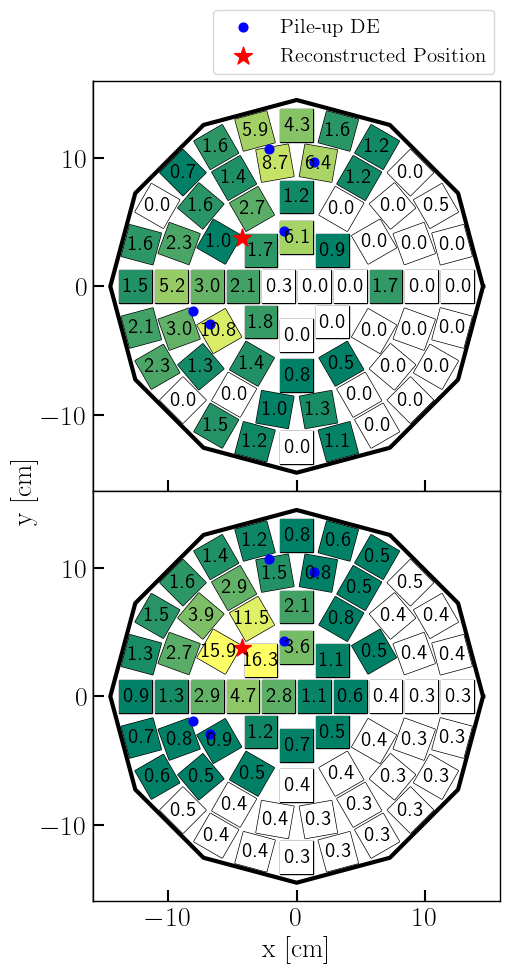

0

In [167]:
pattern_plot_duo(test_DE_sim.pile_up_pe_by_area[3][i],test_DE_sim.pile_up_recons_light_pattern[3][i],
            test_DE_sim.pile_up_result[3][i],
            pos_recons = test_DE_sim.pile_up_pos_recon[3][i], 
            pmt_info = test_DE_sim.pmt_info,
            title = "top_pattern",savefig = True)

DE_sp_cor
=====

In [28]:
test_DE_sim.DE_sp_cor()

last_muon_id.shape:  (54134,)
last_muon_id[-10:]:  [31253 31254 31254 31254 31254 31254 31254 31254 31254 31254]
0
0 54134


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 54134/54134 [00:03<00:00, 14156.43it/s]


平均电子数：  3.208523823304179
last_muon_id.shape:  (58463,)
last_muon_id[-10:]:  [31252 31252 31252 31253 31253 31254 31254 31254 31254 31254]
0
0 58463


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 58463/58463 [00:04<00:00, 14377.03it/s]


平均电子数：  3.488966090733649
last_muon_id.shape:  (6991,)
last_muon_id[-10:]:  [31226 31228 31228 31231 31233 31233 31235 31235 31241 31253]
0
0 6991


...

平均电子数：  4.12492454475741
last_muon_id.shape:  (616,)
last_muon_id[-10:]:  [31176 31199 31200 31201 31201 31209 31214 31218 31231 31248]
0
0 616


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 616/616 [00:00<00:00, 13959.71it/s]


平均电子数：  5.083402832452872
last_muon_id.shape:  (57,)
last_muon_id[-10:]:  [26357 26531 26880 28533 29566 30264 30296 30342 30388 30984]
0
0 57


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 57/57 [00:00<00:00, 20659.81it/s]

平均电子数：  6.063633065154258


In [29]:
test_DE_sim.pile_up_sp_cor[0]

array([5.41069287e+04, 3.11203666e+03, 4.38987422e+01, ...,
       1.11119883e+01, 5.47826321e+00, 1.70216615e+00])

In [30]:
np.sum(test_DE_sim.pile_up_pe_by_area[0][i])

92.9409706101415

CEvNS Sim
=====

In [31]:
test_DE_sim.generate_CEVNS_points()
test_DE_sim.generate_CEVNS_pattern()
test_DE_sim.CEVNS_position_recon()
test_DE_sim.generate_CEVNS_recon_pattern()
test_DE_sim.CEVNS_sp_cor()

Interpn for channel:  0
Interpn for channel:  1
Interpn for channel:  2
Interpn for channel:  3
Interpn for channel:  4
Interpn for channel:  5
Interpn for channel:  6
Interpn for channel:  7
Interpn for channel:  8
Interpn for channel:  9
Interpn for channel:  10
Interpn for channel:  11
Interpn for channel:  12
Interpn for channel:  13
Interpn for channel:  14
Interpn for channel:  15
Interpn for channel:  16
Interpn for channel:  17
Interpn for channel:  18
Interpn for channel:  19
Interpn for channel:  20
Interpn for channel:  21
Interpn for channel:  22
Interpn for channel:  23
Interpn for channel:  24
Interpn for channel:  25
Interpn for channel:  26
Interpn for channel:  27
Interpn for channel:  28
Interpn for channel:  29
Interpn for channel:  30
Interpn for channel:  31
Interpn for channel:  32
Interpn for channel:  33
Interpn for channel:  34
Interpn for channel:  35
Interpn for channel:  36
Interpn for channel:  37
Interpn for channel:  38
Interpn for channel:  39
Interpn fo

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 247455/247455 [00:02<00:00, 113232.68it/s]


Start pos recon for event size:  2
(1, 64)
1
done of generating test files
Start pos recon for event size:  3
(3558330, 64)
3558330
10000 / 3558330 ,time: 0.09264588356018066
20000 / 3558330 ,time: 0.09337568283081055
30000 / 3558330 ,time: 0.08994865417480469
40000 / 3558330 ,time: 0.08935427665710449
50000 / 3558330 ,time: 0.09119153022766113
60000 / 3558330 ,time: 0.09023809432983398
70000 / 3558330 ,time: 0.08964157104492188
80000 / 3558330 ,time: 0.09085822105407715
90000 / 3558330 ,time: 0.09034109115600586
100000 / 3558330 ,time: 0.08965802192687988
110000 / 3558330 ,time: 0.09120059013366699
120000 / 3558330 ,time: 0.08977127075195312
130000 / 3558330 ,time: 0.08929753303527832
140000 / 3558330 ,time: 0.09111809730529785
150000 / 3558330 ,time: 0.09020853042602539
160000 / 3558330 ,time: 0.0901179313659668
170000 / 3558330 ,time: 0.09129834175109863
180000 / 3558330 ,time: 0.09005975723266602
190000 / 3558330 ,time: 0.09127283096313477
200000 / 3558330 ,time: 0.0912284851074218

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 1979.38it/s]

平均电子数：  1.4020802614297085


...

平均电子数：  7.239072102303238
last_muon_id.shape:  (63831,)
last_muon_id[-10:]:  [31253 31253 31253 31253 31253 31254 31254 31254 31254 31254]
0
0 63831


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63831/63831 [00:04<00:00, 14417.43it/s]


平均电子数：  8.275151195157685
last_muon_id.shape:  (27495,)
last_muon_id[-10:]:  [31245 31247 31248 31248 31250 31252 31253 31253 31254 31254]
0
0 27495


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27495/27495 [00:01<00:00, 14357.02it/s]


平均电子数：  9.309851755523642


In [32]:
cevns_points = np.concatenate((test_DE_sim.cevns_points))
# 筛选出有效的sp_cor
# cevns_points = cevns_points[cevns_points['st_cor'] > 0]

In [33]:
def calculate_poisson_probabilities_log(data_array, mean_array):
    # 计算每个元素的对数概率
    log_probabilities = -mean_array + data_array * np.log(mean_array) - gammaln(data_array + 1)
    return log_probabilities

In [34]:
# 定义cevns点的三参数
cevns_info = np.zeros(len(cevns_points),dtype = np.dtype([('area', '<f8'),('st_cor', '<f8'),('pattern', '<f8'),('st_cor_new', '<f8'),('e_num','uint32')]))
cevns_info['area'] = np.sum(cevns_points['pe_by_area'],axis = 1)
cevns_info['st_cor'] = np.log(cevns_points['st_cor'])
# cevns_info['st_cor_new'] = np.log(cevns_points['st_cor_new'])
cevns_info['pattern'] = np.sum(calculate_poisson_probabilities_log(
         cevns_points['pe_by_area'][:,:64], cevns_points['recons_light_pattern'][:,:64]),axis = 1)

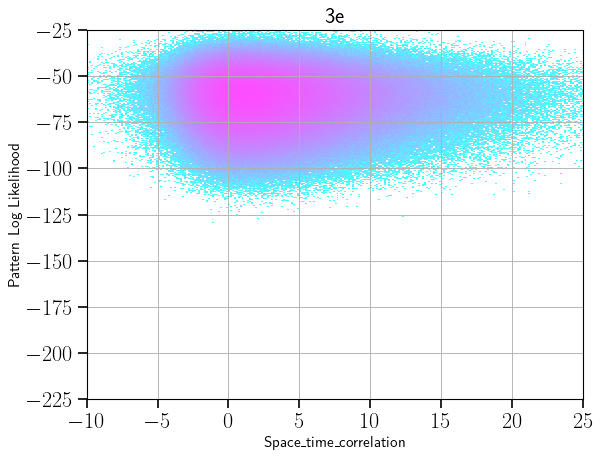

In [35]:
# 绘制二维直方图
fig = plt.figure(figsize=(8, 6), dpi=80)  # 调整 figsize 参数以设置合适的宽度和高度
#plt.hist2d(real_space_time_cor_veto, real_log_l_veto_4, bins=500 , cmap='hot', norm=LogNorm(),alpha = 0.7,label='Real Event')
#plt.colorbar(pad = -0.01)
H = plt.hist2d(cevns_info['st_cor'], cevns_info['pattern'],  bins = 500, cmap='cool', norm=LogNorm(),alpha = 0.7,label = 'DE Event')
#mask = test_DE_sim.CEVNS_sp_cor[0] > 0
# H = plt.hist2d(np.log(test_DE_sim.CEVNS_sp_cor[0][mask]), CEVNS_pattern_possion[0][mask],  bins = 500, cmap='hot', norm=LogNorm(),alpha = 0.7,label = 'CEVNS Event')
plt.xlabel('Space_time_correlation',fontsize = 14)
plt.ylabel('Pattern Log Likelihood',fontsize = 14)
plt.title('3e')
plt.xlim(-10, 25)
plt.ylim(-225,-25)
plt.grid()
plt.savefig("Cevns_dis.png")
plt.show()

In [36]:
mask_point = cevns_info['pattern']> -30
mask_spread = cevns_info['pattern']<-100

3.0
Pattern:  -29.82438339459388


/tmp/ipykernel_16100/1059758695.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("viridis")


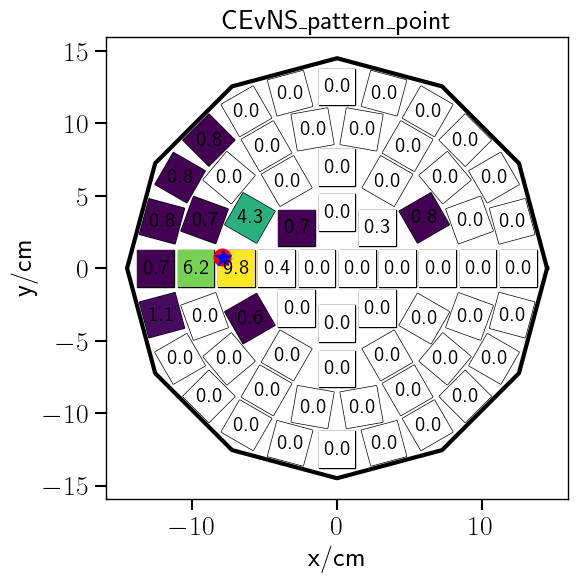

/tmp/ipykernel_16100/1059758695.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("viridis")


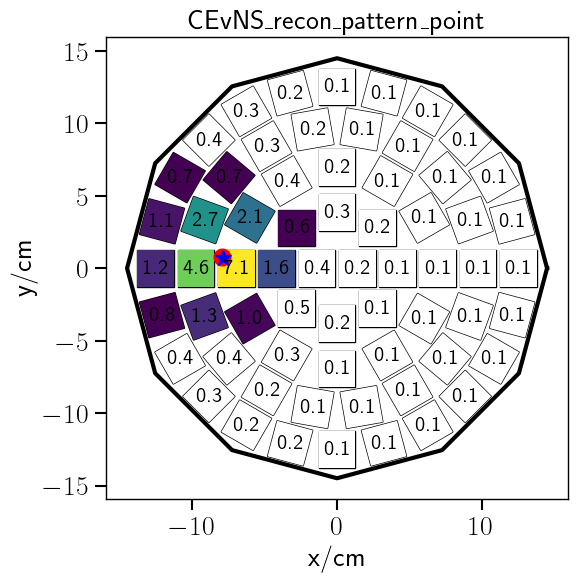

0

In [37]:
i = -1
print(cevns_points[mask_point][i]['num_e'])
print("Pattern: ", cevns_info['pattern'][mask_point][i])
pattern_plot(cevns_points[mask_point][i]['pe_by_area'],
             cevns_points[mask_point][i]['pos_original'],
             cevns_points[mask_point][i]['pos_recon'],
             pmt_info = test_DE_sim.pmt_info,
             title = "CEvNS_pattern_point",
             savefig = True,
            )
pattern_plot(cevns_points[mask_point][i]['recons_light_pattern'],
             cevns_points[mask_point][i]['pos_original'],
             cevns_points[mask_point][i]['pos_recon'],
             pmt_info = test_DE_sim.pmt_info,
             title = "CEvNS_recon_pattern_point",
             savefig = True,
            )

In [38]:
cevns_points.dtype

dtype([('cevnsID', '<i4'), ('pos_original', [('xd', '<f8'), ('yd', '<f8'), ('zd', '<f8')]), ('t', '<f8'), ('num_e', '<f8'), ('light_pattern', '<f8', (128,)), ('pe_pattern', '<u2', (128,)), ('area_pattern', '<f8', (128,)), ('pe_by_area', '<f8', (128,)), ('pos_recon', [('xd', '<f8'), ('yd', '<f8')]), ('recons_light_pattern', '<f8', (128,)), ('st_cor', '<f8'), ('st_cor_new', '<f8')])

9.0
328.53470541904437
Pattern:  -107.1641391137342


/tmp/ipykernel_16100/1059758695.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("viridis")


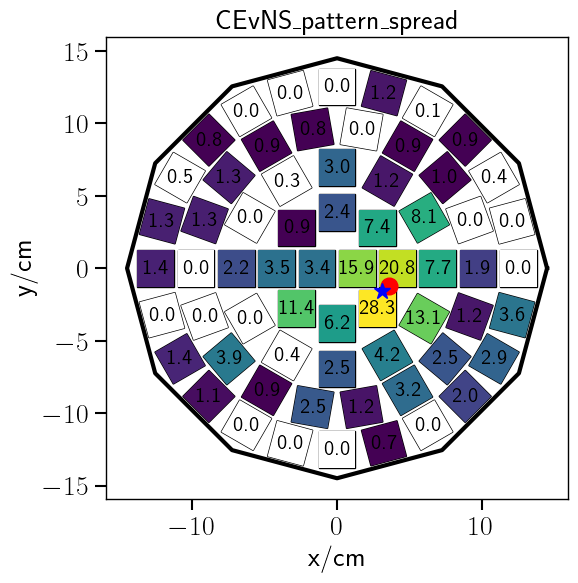

/tmp/ipykernel_16100/1059758695.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("viridis")


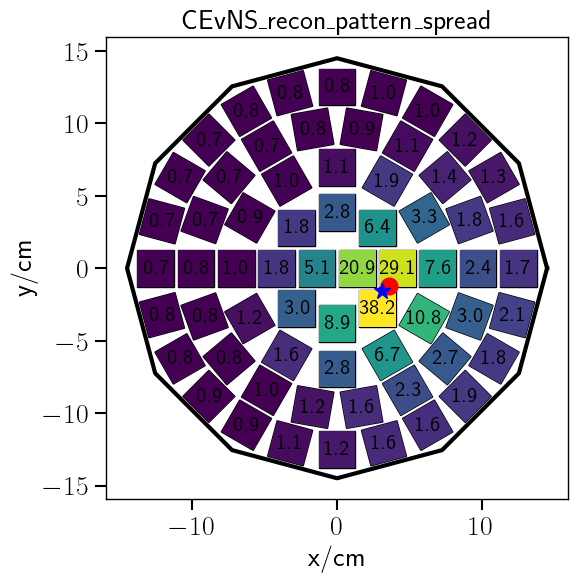

0

In [39]:
i = -1
print(cevns_points[mask_spread][i]['num_e'])
print(np.sum(cevns_points[mask_spread][i]['recons_light_pattern']))
print("Pattern: ", cevns_info['pattern'][mask_spread][i])
pattern_plot(cevns_points[mask_spread][i]['pe_by_area'],
             cevns_points[mask_spread][i]['pos_original'],
             cevns_points[mask_spread][i]['pos_recon'],
             pmt_info = test_DE_sim.pmt_info,
             title = "CEvNS_pattern_spread",
             savefig = True,
            )
pattern_plot(cevns_points[mask_spread][i]['recons_light_pattern'],
             cevns_points[mask_spread][i]['pos_original'],
             cevns_points[mask_spread][i]['pos_recon'],
             pmt_info = test_DE_sim.pmt_info,
             title = "CEvNS_recon_pattern_spread",
             savefig = True,
            )

合并分析
=====

In [42]:
test_DE_sim.pile_up_sp_cor[0],test_DE_sim.cevns_points[0]['st_cor']

(array([6.12313824e+04, 1.68790348e+05, 2.78867752e+04, ...,
        6.39265719e+02, 6.04929055e-01, 1.17213243e+01]),
 array([8.68591331e+01, 3.73522649e+02, 2.40386407e+02, ...,
        7.62525018e+02, 3.21135548e-01, 6.01394734e-01]))

In [54]:
area_pattern.shape

(54, 128)

In [57]:
# test_DE_sim.pile_up_sp_cor
pile_up_sp_cor = np.log(np.concatenate(test_DE_sim.pile_up_sp_cor))
pile_up_n_num = []
for i in range(len(test_DE_sim.pile_up_e_num)):
    num_e = test_DE_sim.pile_up_e_num[i]
    pile_up_n_num.append(np.ones(len(test_DE_sim.pile_up_sp_cor[i]))*num_e)
pile_up_n_num = np.concatenate(pile_up_n_num)

pile_up_pattern = []
pile_up_area = []
for i in range(len(test_DE_sim.pile_up_e_num)):
    area_pattern = test_DE_sim.pile_up_pe_by_area[i]
    recon_pattern = test_DE_sim.pile_up_recons_light_pattern[i]
    pattern = np.sum(calculate_poisson_probabilities_log(
        area_pattern[:,:64],recon_pattern[:,:64]),axis = 1)
    pile_up_pattern.append(pattern)
    area = np.sum(area_pattern,axis = 1)
    pile_up_area.append(area)
pile_up_pattern = np.concatenate(pile_up_pattern)
pile_up_area = np.concatenate(pile_up_area)

In [58]:
pile_up_n_num.shape, pile_up_sp_cor.shape,pile_up_pattern.shape,pile_up_area.shape

((121725,), (121725,), (121725,), (121725,))

In [68]:
cevns_info.dtype

dtype([('area', '<f8'), ('st_cor', '<f8'), ('pattern', '<f8'), ('st_cor_new', '<f8'), ('e_num', '<u4')])

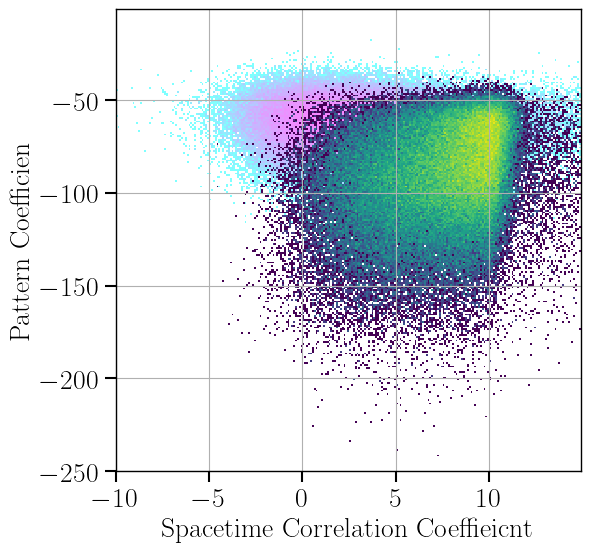

In [112]:
x_bins = np.arange(-10,15,0.1)
y_bins = np.arange(-250,-0,1)

roi_mask_cevns = (cevns_info['area'] > 120) * (cevns_info['area'] < 240)
roi_mask_DE = (pile_up_area > 120) * (pile_up_area < 240)

plt.figure(figsize=(6,6))  # 调整 figsize 参数以设置合适的宽度和高度
#plt.hist2d(real_space_time_cor_veto, real_log_l_veto_4, bins=500 , cmap='hot', norm=LogNorm(),alpha = 0.7,label='Real Event')
#plt.colorbar(pad = -0.01)

H = plt.hist2d(cevns_info['st_cor'], cevns_info['pattern'],  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 0.5,label = 'CEvNS Event', cmap='cool')
H = plt.hist2d(pile_up_sp_cor, pile_up_pattern,  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 1,label = 'CEvNS Event')
#mask = test_DE_sim.CEVNS_sp_cor[0] > 0
# H = plt.hist2d(np.log(test_DE_sim.CEVNS_sp_cor[0][mask]), CEVNS_pattern_possion[0][mask],  bins = 500, cmap='hot', norm=LogNorm(),alpha = 0.7,label = 'CEVNS Event')
plt.xlabel(r'$\mathrm{Spacetime\  Correlation\ Coeffieicnt}$')
plt.ylabel(r'$\mathrm{Pattern\ Coefficien}$')
# plt.title('3e')
plt.grid()
plt.savefig("Pattern_dis.png")
plt.show()

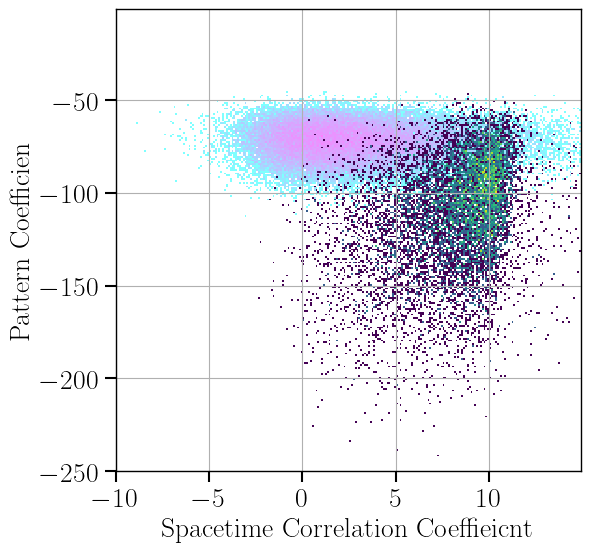

In [113]:
# 绘制二维直方图

x_bins = np.arange(-10,15,0.1)
y_bins = np.arange(-250,-0,1)

roi_mask_cevns = (cevns_info['area'] > 120) * (cevns_info['area'] < 240)
roi_mask_DE = (pile_up_area > 120) * (pile_up_area < 240)

plt.figure(figsize=(6,6))  # 调整 figsize 参数以设置合适的宽度和高度
#plt.hist2d(real_space_time_cor_veto, real_log_l_veto_4, bins=500 , cmap='hot', norm=LogNorm(),alpha = 0.7,label='Real Event')
#plt.colorbar(pad = -0.01)

H = plt.hist2d(cevns_info[roi_mask_cevns]['st_cor'], cevns_info[roi_mask_cevns]['pattern'],  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 0.5,label = 'CEvNS Event', cmap='cool')
H = plt.hist2d(pile_up_sp_cor[roi_mask_DE], pile_up_pattern[roi_mask_DE],  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 1,label = 'CEvNS Event')
#mask = test_DE_sim.CEVNS_sp_cor[0] > 0
# H = plt.hist2d(np.log(test_DE_sim.CEVNS_sp_cor[0][mask]), CEVNS_pattern_possion[0][mask],  bins = 500, cmap='hot', norm=LogNorm(),alpha = 0.7,label = 'CEVNS Event')
plt.xlabel(r'$\mathrm{Spacetime\  Correlation\ Coeffieicnt}$')
plt.ylabel(r'$\mathrm{Pattern\ Coefficien}$')
# plt.title('3e')
plt.grid()
plt.savefig("Pattern_dis_roi.png")
plt.show()

Pattern划分
=====

In [83]:
exposure = []
k_st_list = np.arange(0,50,0.5)
k_area_list = np.arange(0,2.5,0.025)
k_list = []

for k_st in tqdm(k_st_list):
    exposure_k = []
    for k_area in k_area_list:
        score_cevns = cevns_info[roi_mask_cevns]['pattern'] - (k_st * cevns_info[roi_mask_cevns]['st_cor']) + k_area * cevns_info[roi_mask_cevns]['area']
        score_DE = pile_up_pattern[roi_mask_DE] - (k_st * pile_up_sp_cor[roi_mask_DE]) + k_area * pile_up_area[roi_mask_DE]
        
        x = np.percentile(score_DE, 100-0.001)
        exposure_k.append(len(score_cevns[score_cevns>x])/len(score_cevns))
        k_list.append([k_st,k_area,x])
    exposure.append(exposure_k)
exposure = np.array(exposure)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:50<00:00,  1.96it/s]


In [119]:
np.arange(len(k_area_ticks))*10

array([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

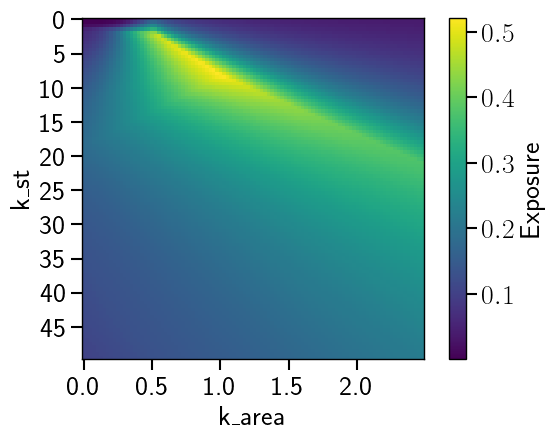

In [128]:
plt.figure()
img = plt.imshow(exposure)

k_st_ticks = np.arange(0,50,5)
k_area_ticks = np.arange(0,2.5,0.5)
# plt.xticks(ticks=np.arange(30), labels=np.arange(0.3,0.6,0.01)) # 设置x轴的刻度位置及对应标签
# plt.yticks(ticks=np.arange(30), labels=np.arange(4,7,0.1)) # 设置y轴的刻度位置及对应标签
plt.xticks(ticks=(np.arange(len(k_area_ticks))*20), labels=k_area_ticks)  # 设置x轴的刻度位置及对应标签
plt.yticks(ticks=(np.arange(len(k_st_ticks))*10), labels=k_st_ticks)  # 设置y轴的刻度位置及对应标签

# 添加 colorbar
plt.colorbar(img, label='Exposure')

plt.xlabel("k_area")
plt.ylabel("k_st")
plt.tight_layout()
plt.savefig("param_scan.png")
plt.show()

In [126]:
index_of_max = np.argmax(exposure)
print(k_list[index_of_max],np.max(exposure))
k_st, k_area, b = k_list[index_of_max]
b = -b

[7.5, 0.9500000000000001, 52.08277655030202] 0.5214365380325675


In [102]:
score_cevns = cevns_info[roi_mask_cevns]['pattern'] - (k_st * cevns_info[roi_mask_cevns]['st_cor']) + k_area * cevns_info[roi_mask_cevns]['area'] + b
score_DE = pile_up_pattern[roi_mask_DE] - (k_st * pile_up_sp_cor[roi_mask_DE]) + k_area * pile_up_area[roi_mask_DE] + b

In [107]:
# 设定分数阈值的范围
thresholds = np.arange(-300, 200, 1)  # 你可以调整这个范围和步长以适应你的数据

# 初始化两个比例的列表
left_DE_ratios = []
right_cevns_ratios = []

# 计算每个阈值下的比例
for threshold in thresholds:
    left_DE_ratio = np.sum(score_DE < threshold) / len(score_DE)
    right_cevns_ratio = np.sum(score_cevns > threshold) / len(score_cevns)
    
    left_DE_ratios.append(left_DE_ratio)
    right_cevns_ratios.append(right_cevns_ratio)

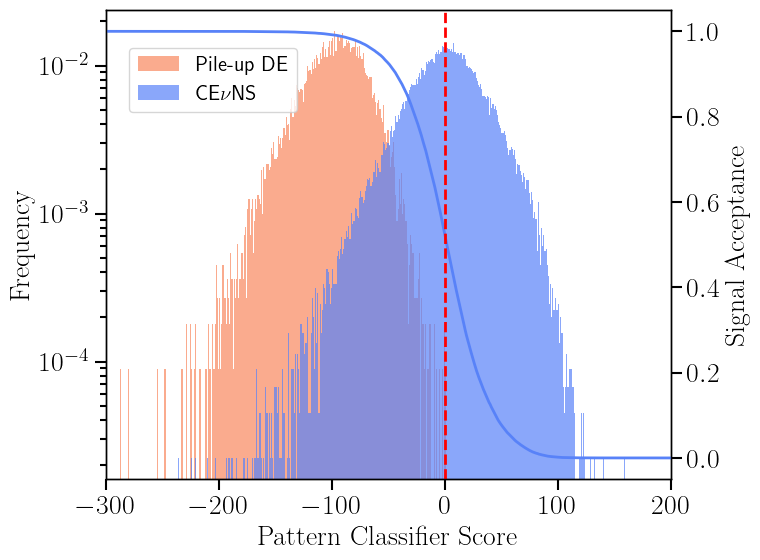

In [127]:
# 导入所需要的库
import matplotlib.pyplot as plt
import numpy as np

cevns_color = '#5882F8'
DE_color = '#F9885E'

# 创建一个新的图形并设置大小
fig, ax1 = plt.subplots(figsize=(8,6))
plt.rcParams['text.usetex'] = True

# 开始处理第一个图，使用左侧y轴

color = 'tab:blue'
bins = np.arange(-300, 200, 1)
ax1.hist(score_DE, bins=bins, log=True, label='Pile-up DE', alpha=0.7, color=DE_color,density = True)  # 添加 alpha 参数
ax1.hist(score_cevns, bins=bins, log=True, label=r"CE$\nu$NS", alpha=0.7, color=cevns_color,density = True)  # 添加 alpha 参数
ax1.set_ylabel(r'$\mathrm{Frequency}$')  # 右侧y轴标签
ax1.set_xlabel(r'$\mathrm{Pattern\ Classifier\ Score}$')  # x轴标签
ax1.tick_params(axis='y')  # y轴标签颜色

# 第二个图，使用右侧y轴
ax2 = ax1.twinx() 
ax2.set_ylabel(r'$\mathrm{Signal\ Acceptance}$')  # 左侧y轴标签
# ax2.plot(thresholds, left_DE_ratios, label='Pile-up Cut Rate', color= DE_color)  # 绘制左侧 DE 的比例曲线
ax2.plot(thresholds, right_cevns_ratios, label=r"CE$\nu$NS Survival Rate", color=cevns_color)  # 绘制右侧 CEVNS 的比例曲线
# ax2.grid(True)
ax2.tick_params(axis='y')  # y轴标签颜色


# 获得所有子图的 legend labels 和 handles
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# 创建一个全局的legend
# fig.legend(lines + lines2, labels + labels2, loc=(0.65,0.71))
fig.legend(lines, labels, loc=(0.17,0.8))

# fig.tight_layout(pad = 5)  # 使布局紧密
# plt.title('Pattern Classifier', fontsize=16)  # 图表标题
plt.xlim(-300, 200)
plt.axvline(x=0, color='red', linestyle='dashed')
plt.tight_layout() 
plt.savefig("pattern_classifier_score.png")
plt.show()  # 显示绘图
